### Pacotes importados

In [1]:
import Pkg
Pkg.add("Plots")

using Plots
using LinearAlgebra

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Manifest.toml`


## Chapter 10: Newton's local method

### Algorithm 10.1: Newton's local method

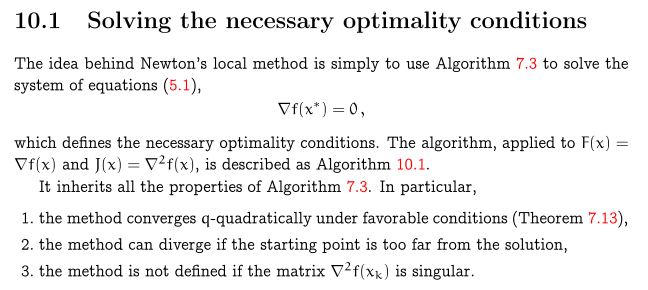

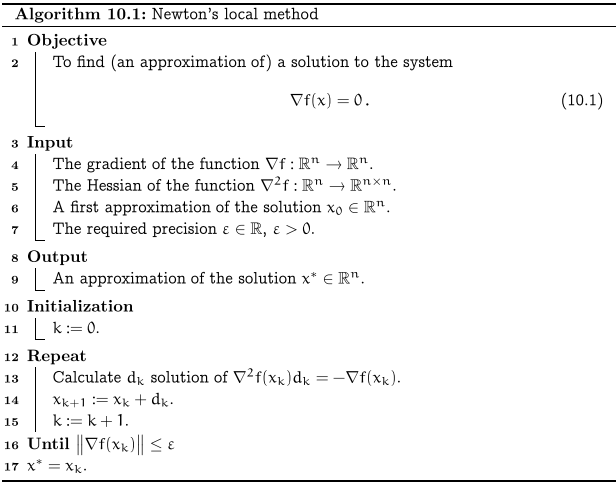

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$; $x_0 = [1.0, 1.0]$

In [2]:
function newton_otimizacao_plot(gradf, hessf, x0, epi; max_iter=100)
    x = copy(x0)

    xs = [copy(x)]
    erros = [norm(gradf(x))]

    k = 0

    while norm(gradf(x)) > epi && k < max_iter
        d = hessf(x) \ (-gradf(x))   # resolve H d = -∇f
        x = x + d

        push!(xs, copy(x))
        push!(erros, norm(gradf(x)))

        k += 1
    end

    return x, xs, erros, k
end

using Plots

function plot_newton_otimizacao(gradf, hessf, x0, epi; titulo="Newton Otimização")
    x_aprox, xs, erros, iter = newton_otimizacao_plot(gradf, hessf, x0, epi)

    k_vals = 0:length(xs)-1
    x1_vals = [x[1] for x in xs]
    x2_vals = [x[2] for x in xs]

    println("Solução aproximada: ", x_aprox)
    println("Iterações: ", iter)
    println("Norma do gradiente final: ", erros[end])

    p1 = plot(
        k_vals,
        x1_vals,
        marker=:circle,
        linewidth=2,
        xlabel="Iteração",
        ylabel="Valor",
        title="Convergência - $titulo",
        label="x₁"
    )

    plot!(
        p1,
        k_vals,
        x2_vals,
        marker=:diamond,
        linewidth=2,
        label="x₂"
    )

    p2 = plot(
        k_vals,
        erros,
        marker=:circle,
        linewidth=2,
        yscale=:log10,
        xlabel="Iteração",
        ylabel="||∇f(xₖ)||",
        title="Erro - $titulo",
        label="Gradiente"
    )

    display(p1)
    display(p2)

    return x_aprox, iter
end

plot_newton_otimizacao (generic function with 1 method)

Solução aproximada: [1.9904427227528804e-17, 1.5707963267948966]
Iterações: 4
Norma do gradiente final: 8.354257125844333e-17


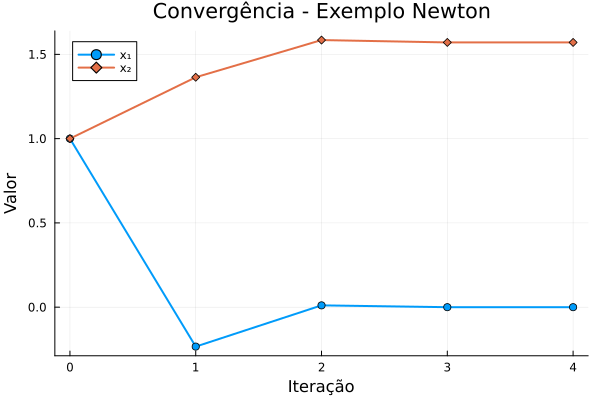

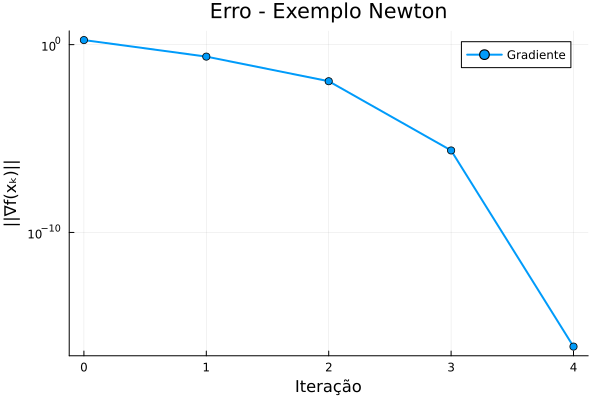

([1.9904427227528804e-17, 1.5707963267948966], 4)

In [3]:
gradf(x) = [
    x[1] + cos(x[2]);
    -x[1]*sin(x[2])
]

hessf(x) = [
    1          -sin(x[2]);
    -sin(x[2])  -x[1]*cos(x[2])
]

x0 = [1.0, 1.0]
epi = 1e-10

plot_newton_otimizacao(gradf, hessf, x0, epi, titulo="Exemplo Newton")

### Algorithm 10.2: Newton's local method by quadratic modeling

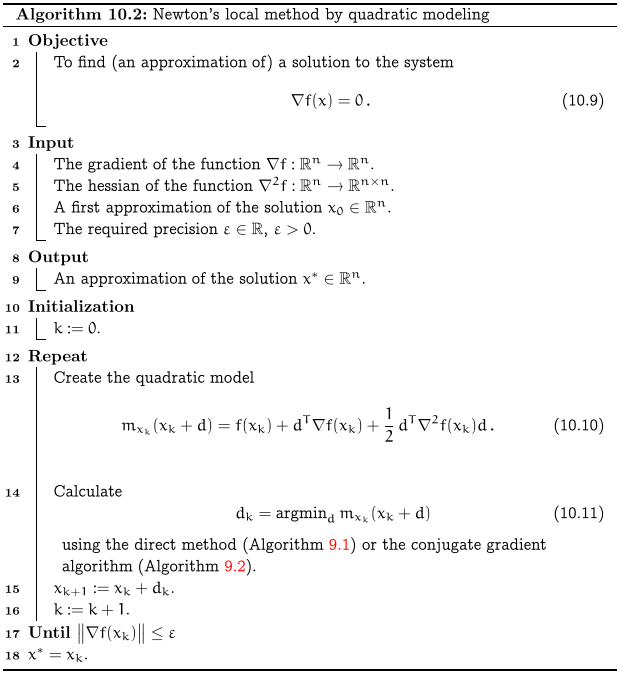

We test the algorithm on the Rosenbrock function. It is described in Section 11.6 of the book for two variables.  The implementation below involves $n$ variables: \\[f(x) = \sum_{i=1}^{n-1} f_i(x) = \sum_{i=1}^{n-1} 100 (x_{i+1}-x_i^2)^2 + (1-x_i)^2.\\]
The calculation of the derivatives is based on the partial derivatives of the functions $f_i$:
\\[
\begin{array}{rcl}
\partial f_i/\partial x_i&=& -400 x_i (x_{i+1}-x_i^2) - 2(1-x_i), \\\\
\partial f_i/\partial x_{i+1}&=& 200 (x_{i+1}-x_i^2), \\\\
\partial^2 f_i/\partial x^2_i  &=& -400 x_{i+1}+ 1200 x_i^2 + 2, \\\\
\partial^2 f_i/\partial x_i \partial x_{i+1}  &=& -400 x_i^2, \\\\
\partial^2 f_i/\partial x^2_{i+1}  &=& 200. 
\end{array}
\\]

In [5]:
function newton_quadratico(f, gradf, hessf, x0, epi; max_iter=100)
    x = copy(x0)

    xs = [copy(x)]
    erros = [norm(gradf(x))]
    valores = [f(x)]

    k = 0

    while norm(gradf(x)) > epi && k < max_iter
        g = gradf(x)
        H = hessf(x)

        # resolve subproblema quadrático
        d = H \ (-g)

        x = x + d

        push!(xs, copy(x))
        push!(erros, norm(gradf(x)))
        push!(valores, f(x))

        k += 1
    end

    return x, xs, erros, valores, k
end

using Plots

function plot_newton_quadratico(f, gradf, hessf, x0, epi; titulo="Newton Quadrático")
    x_aprox, xs, erros, valores, iter = newton_quadratico(f, gradf, hessf, x0, epi)

    k_vals = 0:length(xs)-1
    x1_vals = [x[1] for x in xs]
    x2_vals = [x[2] for x in xs]

    println("Solução aproximada: ", x_aprox)
    println("Iterações: ", iter)
    println("Gradiente final: ", erros[end])
    println("Valor final f(x): ", valores[end])

    # Trajetória das variáveis
    p1 = plot(
        k_vals,
        x1_vals,
        marker=:circle,
        linewidth=2,
        xlabel="Iteração",
        ylabel="Valor",
        title="Convergência - $titulo",
        label="x₁"
    )

    plot!(p1, k_vals, x2_vals, marker=:diamond, linewidth=2, label="x₂")

    # Erro (gradiente)
    p2 = plot(
        k_vals,
        erros,
        marker=:circle,
        linewidth=2,
        yscale=:log10,
        xlabel="Iteração",
        ylabel="||∇f(xₖ)||",
        title="Erro - $titulo",
        label="Gradiente"
    )

    # Valor da função
    p3 = plot(
        k_vals,
        valores,
        marker=:circle,
        linewidth=2,
        xlabel="Iteração",
        ylabel="f(xₖ)",
        title="Valor da função - $titulo",
        label="f(x)"
    )

    display(p1)
    display(p2)
    display(p3)

    return x_aprox
end

plot_newton_quadratico (generic function with 1 method)

Solução aproximada: [-0.9620510206947501, 0.9357393959767101, 0.8807136041943205, 0.7778776758544063, 0.6050936785926528]
Iterações: 13
Gradiente final: 9.523312941435512e-14
Valor final f(x): 3.9308394341330275


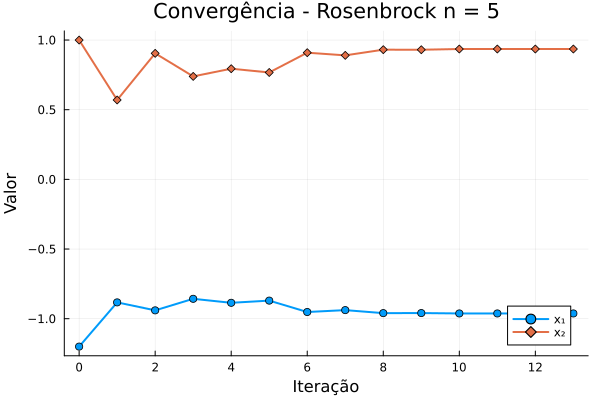

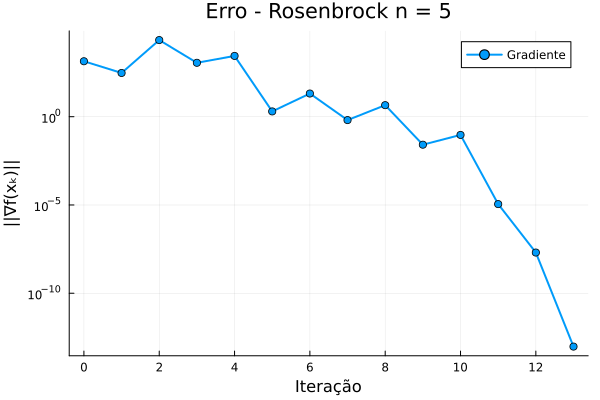

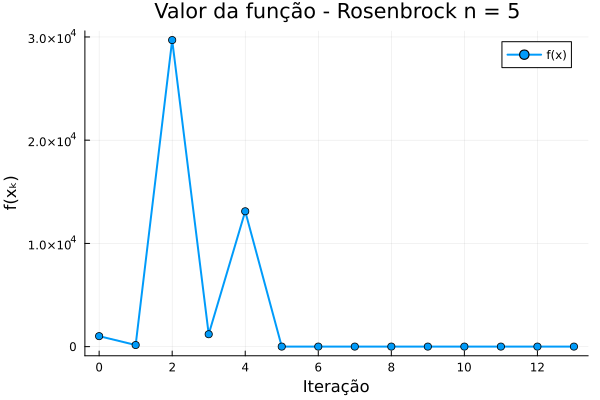

5-element Vector{Float64}:
 -0.9620510206947501
  0.9357393959767101
  0.8807136041943205
  0.7778776758544063
  0.6050936785926528

In [9]:
function rosenbrock(x)
    n = length(x)
    soma = 0.0

    for i in 1:n-1
        soma += 100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2
    end

    return soma
end

function grad_rosenbrock(x)
    n = length(x)
    g = zeros(n)

    for i in 1:n-1
        g[i] += -400*x[i]*(x[i+1] - x[i]^2) - 2*(1 - x[i])
        g[i+1] += 200*(x[i+1] - x[i]^2)
    end

    return g
end

function hess_rosenbrock(x)
    n = length(x)
    H = zeros(n, n)

    for i in 1:n-1
        H[i,i] += -400*x[i+1] + 1200*x[i]^2 + 2
        H[i,i+1] += -400*x[i]
        H[i+1,i] += -400*x[i]
        H[i+1,i+1] += 200
    end

    return H
end

n = 5

x0 = fill(-1.2, n)
x0[2:2:end] .= 1.0

epi = 1e-10

plot_newton_quadratico(
    rosenbrock,
    grad_rosenbrock,
    hess_rosenbrock,
    x0,
    epi,
    titulo="Rosenbrock n = 5"
)

We now apply the algorithm on example 5.8. In this case, the algorithm fails to converge, and one hessian is not positive definite. We try first using the direct method to solve the quadratic problem. An error is triggered. 

In [10]:
function newton_quadratico_2(f, gradf, hessf, x0, epi; max_iter=100)
    x = copy(x0)

    xs = [copy(x)]
    erros = [norm(gradf(x))]

    k = 0

    while norm(gradf(x)) > epi && k < max_iter
        g = gradf(x)
        H = hessf(x)

        # regularização
        H = H + 1e-6*I

        d = H \ (-g)

        # garantir descida
        if dot(d, g) > 0
            d = -g
        end

        x = x + d

        push!(xs, copy(x))
        push!(erros, norm(gradf(x)))

        k += 1
    end

    return x, xs, erros, k
end

newton_quadratico_2 (generic function with 1 method)

Solução aproximada: [1.9904427227528804e-17, 1.5707963267948966]
Iterações: 4
Gradiente final: 8.354257125844333e-17
Valor final f(x): 1.4168877662807238e-33


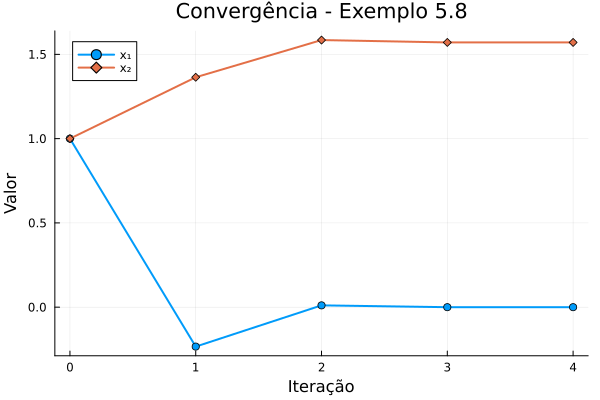

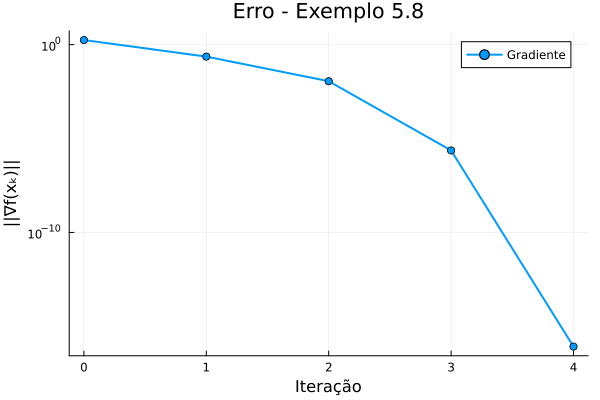

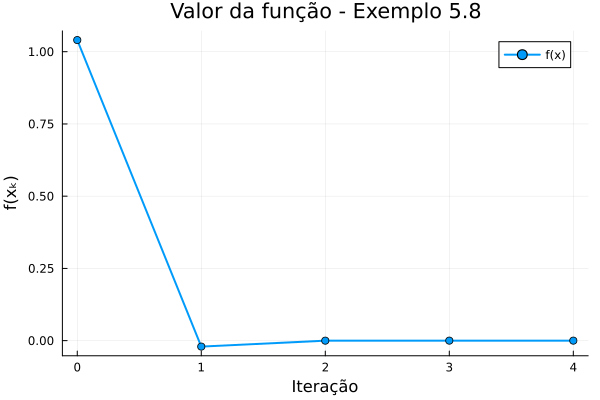

2-element Vector{Float64}:
 1.9904427227528804e-17
 1.5707963267948966

In [11]:
f(x) = 0.5*x[1]^2 + x[1]*cos(x[2])

gradf(x) = [
    x[1] + cos(x[2]);
    -x[1]*sin(x[2])
]

hessf(x) = [
    1.0        -sin(x[2]);
    -sin(x[2]) -x[1]*cos(x[2])
]

x0 = [1.0, 1.0]
epi = 1e-10

plot_newton_quadratico(
    f,
    gradf,
    hessf,
    x0,
    epi,
    titulo="Exemplo 5.8"
)

In [12]:
H0 = hessf(x0)

println("Hessiana em x0:")
println(H0)

println("Autovalores:")
println(eigvals(H0))

cholesky(H0) # Cholesky falha porque H0 não é positiva definida aaaaaa vai dar erro mas ta certo, eu acho.

Hessiana em x0:
[1.0 -0.8414709848078965; -0.8414709848078965 -0.5403023058681398]
Autovalores:
[-0.910855416378039, 1.3705531105098994]


LoadError: PosDefException: matrix is not positive definite; Factorization failed.

If we try with the conjugate gradient method, an error is also triggered. 

In [ ]:
function cg_quadratico(H, g; max_iter=100, epi=1e-10)
    d = zeros(length(g))
    r = -g - H*d
    p = copy(r)

    for k in 1:max_iter
        Hp = H*p
        denom = dot(p, Hp)

        if denom <= 0
            error("Erro: matriz não definida positiva. Gradiente conjugado falhou.")
        end

        α = dot(r, r) / denom
        d = d + α*p
        r_new = r - α*Hp

        if norm(r_new) < epi
            return d, k
        end

        β = dot(r_new, r_new) / dot(r, r)
        p = r_new + β*p
        r = r_new
    end

    return d, max_iter
end

f(x) = 0.5*x[1]^2 + x[1]*cos(x[2])

gradf(x) = [
    x[1] + cos(x[2]);
    -x[1]*sin(x[2])
]

hessf(x) = [
    1.0        -sin(x[2]);
    -sin(x[2]) -x[1]*cos(x[2])
]

x0 = [1.0, 1.0]

g = gradf(x0)
H = hessf(x0)

println("Hessiana:")
println(H)

println("Autovalores da Hessiana:")
println(eigvals(H))

d, iter = cg_quadratico(H, g)

println("Direção encontrada: ", d)
println("Iterações CG: ", iter) 

Hessiana:
[1.0 -0.8414709848078965; -0.8414709848078965 -0.5403023058681398]
Autovalores da Hessiana:
[-0.910855416378039, 1.3705531105098994]


LoadError: Erro: matriz não definida positiva. Gradiente conjugado falhou.

  Julia 1.12 has introduced more strict world age semantics for global bindings.
  !!! This code may malfunction under Revise.
  !!! This code will error in future versions of Julia.
Hint: Add an appropriate `invokelatest` around the access to this binding.
To make this warning an error, and hence obtain a stack trace, use `julia --depwarn=error`.
